#### Compare the EDC of the measured RIR to the DiffGFDN RIR in e8_gfdn.py

In [1]:
from pathlib import Path
import importlib
import torch
import soundfile as sf
import numpy as np
import matplotlib.pyplot as plt
from slope2noise.utils import db, schroeder_backward_int
import examples.e8_gfdn as e8_gfdn

# Reload so the notebook model architecture follows the current example
# (not a stale definition retained by this notebook kernel).
importlib.reload(e8_gfdn)
GroupedFDN = e8_gfdn.GroupedFDN

#### Plotting functions

In [2]:
def plot_rir_spectrogram(
    rir,
    fs,
    n_fft=2048,
    hop_length=512,
    win_length=None,
    title="RIR Spectrogram",
    figsize=(6, 4),
    cmap="magma",
    vmin=None,
    vmax=0,
):
    """
    Plot the log-magnitude spectrogram of an RIR.
    Parameters
    ----------
    rir : torch.Tensor or numpy.ndarray
        Room impulse response. Shape can be:
        - (samples,)
        - (channels, samples)
        If multi-channel, the channels are averaged before plotting.
    fs : int
        Sampling frequency in Hz.
    n_fft : int
        FFT size.
    hop_length : int
        Number of samples between successive STFT frames.
    win_length : int or None
        Window length. Defaults to n_fft.
    title : str
        Plot title.
    figsize : tuple
        Figure size.
    cmap : str
        Matplotlib colormap. "magma" is recommended.
    vmin : float or None
        Minimum dB value displayed. If None, it is set to
        vmax - 80 dB.
    vmax : float
        Maximum dB value displayed.

    Returns
    -------
    fig, ax, S_db
        Matplotlib figure, axes, and spectrogram in dB.
    """

    # Convert to tensor
    if not isinstance(rir, torch.Tensor):
        rir = torch.tensor(rir)

    rir = rir.detach().float()

    # Handle multi-channel RIR
    if rir.ndim == 2:
        rir = rir.mean(dim=0)

    if rir.ndim != 1:
        raise ValueError(
            "rir must have shape (samples,) or (channels, samples)"
        )

    if win_length is None:
        win_length = n_fft

    # Window
    window = torch.hann_window(
        win_length,
        device=rir.device,
        dtype=rir.dtype,
    )

    # STFT
    stft = torch.stft(
        rir,
        n_fft=n_fft,
        hop_length=hop_length,
        win_length=win_length,
        window=window,
        return_complex=True,
    )

    # Magnitude
    magnitude = torch.abs(stft)

    # Convert to dB relative to maximum
    magnitude_db = db(magnitude)
    S_db = magnitude_db.cpu().numpy()

    # Time and frequency axes
    times = torch.arange(
        S_db.shape[1]
    ) * hop_length / fs

    freqs = torch.arange(
        S_db.shape[0]
    ) * fs / n_fft

    times = times.numpy()
    freqs = freqs.numpy()

    # Plot
    fig, ax = plt.subplots(figsize=figsize)

    if vmin is None:
        vmin = vmax - 80

    im = ax.pcolormesh(
        times,
        freqs,
        S_db,
        shading="auto",
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
    )

    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Frequency (Hz)")
    ax.set_title(title)

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("Magnitude (dB)")

    ax.set_ylim(0, fs / 2)
    ax.set_xlim(0, 1.0)

    fig.tight_layout()

def plot_and_compare_edc(rir1, rir2, fs):
    """Plot and compare the EDCs of two RIRs"""
    len_rir = min(len(rir1), len(rir2))
    rir1_edc = schroeder_backward_int(rir1[:len_rir])
    rir2_edc = schroeder_backward_int(rir2[:len_rir])
    time_axis = np.arange(0, len_rir/fs, 1.0/fs) 
    
    plt.figure()
    plt.plot(time_axis, db(rir1_edc, is_squared=True), label='Reference')
    plt.plot(time_axis, db(rir2_edc, is_squared=True), label='Optimised GFDN')
    plt.xlabel('time (s)')
    plt.ylabel('Energy (dB)')
    plt.xlim([0, 1.2])
    plt.legend()
    plt.grid()
    plt.show()


def plot_gfdn_peq_group_responses(attenuation, fs: float, n_groups=None):
    """Plot the total PEQ response of each delay-line group.

    The response includes the optional final shelf when ``is_twostage``
    is enabled. ``n_groups`` defaults to the filter's own grouping.
    """
    if n_groups is None:
        n_groups = attenuation.n_groups
    if n_groups != attenuation.n_groups:
        raise ValueError("n_groups must match attenuation.n_groups")

    with torch.no_grad():
        H = attenuation.freq_response(attenuation.param).detach().cpu()

    # A two-stage PEQ should still return its complete cascade as
    # (frequency_bins, delay_lines). Accept a singleton batch axis for
    # checkpoints made with older filter implementations.
    if H.ndim == 3 and H.shape[0] == 1:
        H = H.squeeze(0)
    if H.ndim != 2:
        raise RuntimeError(
            f"Expected response shape (frequency_bins, delay_lines), got {tuple(H.shape)}"
        )

    nfft = attenuation.nfft
    n_delays = H.shape[1]
    if n_delays % n_groups:
        raise ValueError("The number of delay lines must be divisible by n_groups")
    group_size = n_delays // n_groups

    freqs = torch.fft.rfftfreq(
        nfft,
        d=1.0 / fs,
    ).numpy()

    H_db = 20 * torch.log10(
        torch.clamp(torch.abs(H), min=1e-12)
    ).numpy()

    plt.figure(figsize=(10, 6))

    for g in range(n_groups):

        start = g * group_size
        end = (g + 1) * group_size

        for d in range(start, end):
            plt.plot(
                freqs,
                H_db[:, d],
                alpha=0.35,
            )

        # Average magnitude response of the group
        group_H_db = H_db[:, start:end].mean(axis=1)

        plt.plot(
            freqs,
            group_H_db,
            linewidth=3,
            label=f"Group {g}",
        )

    plt.xscale("log")
    plt.xlim(20, fs / 2)
    plt.ylim(-60, 20)

    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Magnitude (dB)")
    plt.title("Final grouped PEQ responses")

    plt.grid(True, which="both", alpha=0.25)
    plt.legend()

    plt.tight_layout()
    plt.show()

    return freqs, H_db

#### Compare spectrogram and EDCs of reference and optimised RIRs

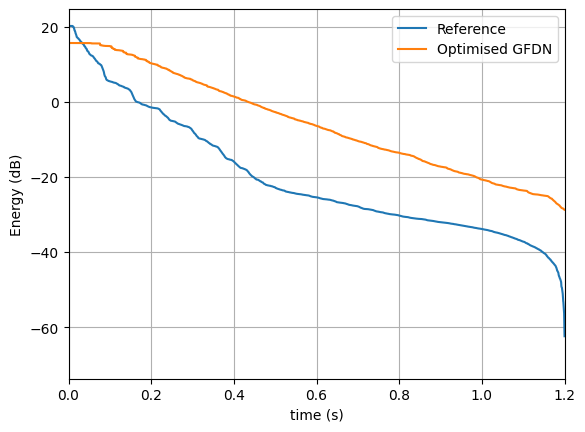

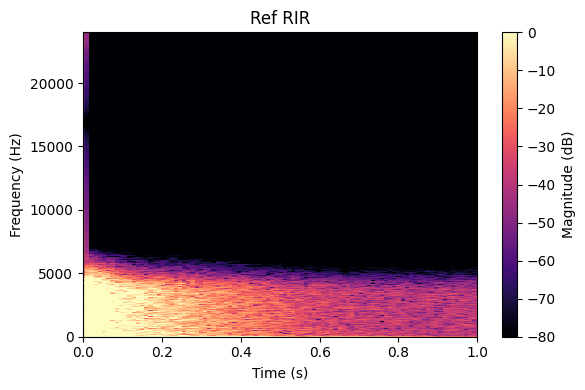

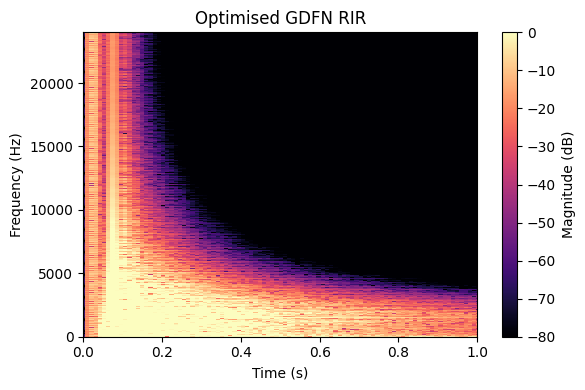

In [3]:
output_path = Path('../output/20260925-142127').resolve()
ref_path = Path('../rirs/multi-slope/ertd1_rir_r1.wav').resolve()
ref_rir, fsr = sf.read(str(ref_path))
opt_rir, fso = sf.read(str(f'{output_path}/ir_optim.wav'))

assert fsr == fso, "Reference and optimised RIR sample rates do not match"

plot_and_compare_edc(ref_rir, opt_rir, float(fsr))
plot_rir_spectrogram(ref_rir, float(fsr), title='Ref RIR')
plot_rir_spectrogram(opt_rir, float(fsr), title='Optimised GDFN RIR')

#### Plot the attenuation filter frequency responses

/Users/k2478454/Documents/FDN/GroupedFDN/BlindGFDN/flamo/flamo/auxiliary/reverb.py:975: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  bias = torch.tensor(


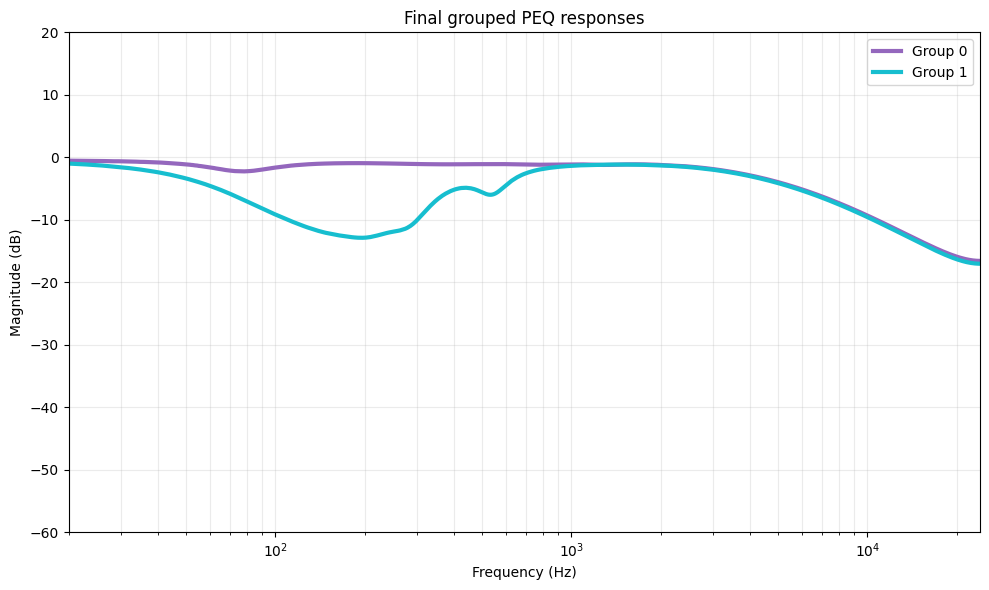

In [4]:
# Architecture parameters
nfft = 96000
fs = 48000
n_groups = 2
group_size = 4
delays = [997, 1153, 1327, 1559]
delay_lengths = delays * n_groups
alias_decay_db = 30

checkpoint_path = f'{output_path}/checkpoints/model_e19.pt'
checkpoint = torch.load(checkpoint_path, map_location='cpu')

# The attenuation parameter has one extra section for a two-stage PEQ.
attenuation_key = '_Shell__core.feedback_loop.feedback.attenuation.param'
n_sections = checkpoint[attenuation_key].shape[0]
if n_sections not in (8, 9):
    raise ValueError(f'Unexpected PEQ section count in checkpoint: {n_sections}')
is_twostage = n_sections == 9

# Create the architecture that matches this checkpoint.
model = GroupedFDN(
    group_size=group_size,
    n_groups=n_groups,
    delay_lengths=delay_lengths,
    nfft=nfft,
    fs=fs,
    in_ch=1,
    out_ch=1,
    rt_dc=1.0,
    rt_nyquist=0.2,
    crossover_freq=4000.0,
    is_twostage=is_twostage,
    alias_decay_db=alias_decay_db,
    device="cpu",
    dtype=torch.float64,
)
model.load_state_dict(checkpoint)
model.eval()

core = model.get_core()
attenuation = core.feedback_loop.feedback.attenuation

freqs, H_db = plot_gfdn_peq_group_responses(
    attenuation,
    fs=fs,
    n_groups=n_groups,
)